In [1]:
import sys
sys.path.append("D:/metal-flow/src/metal_flow")

Generating Launchpads...
Generating CoupledLineTee
Connecting...
Generating Qubits...
Generating Readout Resonators...
Generating Couplers...


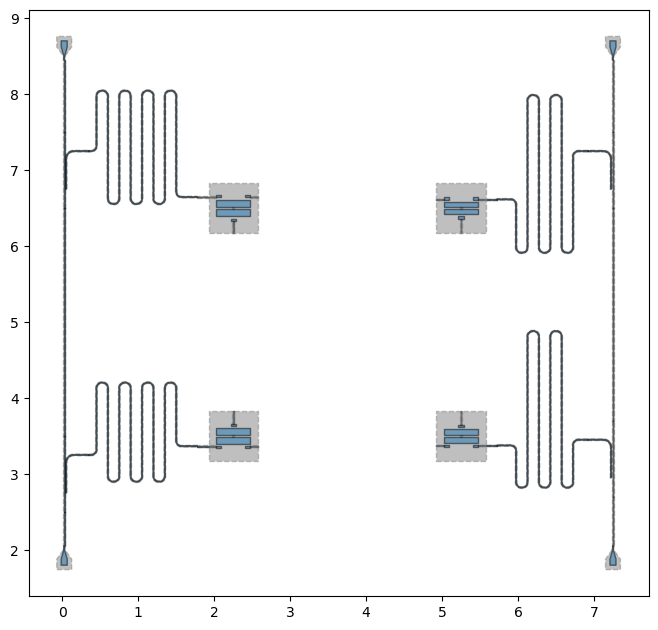

In [2]:
from qiskit_metal import Dict, view
from functions import create_design


FOUR_QUBIT_DESIGN_DICT = Dict(
    # Define the overall dimensions of the planar silicon chip
    chip_size = Dict(
        size_x = '10mm',
        size_y = '10mm',
        size_z = '-280um',
        centre_x = '4mm',
        centre_y = '5mm'
    ),

    # Define standard Coplanar Waveguide (CPW) parameters used across the chip
    cpw_dims = Dict(
        width = '10 um',
        gap = '6 um'
    ),

    

    # Substrate and metal film thickness for EM simulations (Ansys Q3D/HFSS)
    physical_params = Dict(
        substrate_thickness = 280e-6,
        film_thickness = 200e-9
    ),

    # Locations and orientations of the 4 wirebond launchpads for I/O
    launchpad_options = Dict(
        p0 = Dict(pos_x='25um' , pos_y='8500um', orientation='-90', lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p1 = Dict(pos_x='7250um', pos_y='8500um', orientation='-90', lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p2 = Dict(pos_x='25um' , pos_y='2000um' , orientation='90', lead_length='50 um', pad_width='80 um', pad_height='80 um'),
        p3 = Dict(pos_x='7250um', pos_y='2000um' , orientation='90', lead_length='50 um', pad_width='80 um', pad_height='80 um')
    ),


    cpw_default_options = Dict(chip='main', hfss_wire_bonds=True),


    feedline_connections = [Dict(start_pin=Dict(component='p0', pin='tie'), end_pin=Dict(component='ctl0', pin='prime_end')), 
                            
                            Dict(start_pin=Dict(component='ctl0', pin='prime_start'), end_pin=Dict(component='ctl2', pin='prime_end')),
                            
                            Dict(start_pin=Dict(component='ctl2', pin='prime_start'), end_pin=Dict(component='p2', pin='tie')),
                            
                            Dict(start_pin=Dict(component='p1', pin='tie'), end_pin=Dict(component='ctl1', pin='prime_start')), 
                            
                            Dict(start_pin=Dict(component='ctl1', pin='prime_end'), end_pin=Dict(component='ctl3', pin='prime_start')),
                            
                            Dict(start_pin=Dict(component='ctl3', pin='prime_end'), end_pin=Dict(component='p3', pin='tie'))

    ],


    # Locations, orientations, and GDS generation names for the 4 Transmon qubits
    qubit_options = Dict(
        q0 = Dict(pos_x='2250um', pos_y='6500um', orientation='0', gds_cell_name='Chip0725_auto', pad_width= '450 um', pad_height= "100 um", pad_gap = '20 um'),#, pocket_width='1100 um', pocket_height='1100 um'),
        q1 = Dict(pos_x='5250um', pos_y='6500um', orientation='0', gds_cell_name='Chip0726_auto', pad_width= '450 um', pad_height= "70 um" , pad_gap = '20 um'), #, pocket_width='1100 um', pocket_height='1100 um'),
        q2 = Dict(pos_x='2250um', pos_y='3500um', orientation='0', gds_cell_name='Chip0727_auto', pad_width= '450 um', pad_height= "90 um" , pad_gap = '20 um'), #, pocket_width='1100 um', pocket_height='1100 um'),
        q3 = Dict(pos_x='5250um', pos_y='3500um', orientation='0', gds_cell_name='Chip0728_auto', pad_width= '450 um', pad_height= "80 um" , pad_gap = '20 um')  #, pocket_width='1100 um', pocket_height='1100 um')
    ),

    # Default geometry parameters for the TransmonPocket6 components, including coupling pads
    transmon_defaults = Dict(
        connection_pads=dict(
            resonator_pad = dict(pad_width='70um', cpw_extend='150um', pad_gap='30um'),
            coupler_short_pad = dict(pad_width='70um', cpw_extend='0um', pad_gap='30um'),
            coupler_long_pad = dict(pad_width='70um', cpw_extend='0um', pad_gap='30um')
        )
    ),

    # Explicitly defining the pad placement (Width/Height directional vectors) for each qubit
    # to ensure routing doesn't cross over itself
    qubit_pad_placements = Dict(
        q0 = Dict(resonator_pad=Dict(loc_W=-1, loc_H=+1), coupler_short_pad=Dict(loc_W=+1, loc_H=+1), coupler_long_pad=Dict(loc_W=0, loc_H=-1)),
        q1 = Dict(resonator_pad=Dict(loc_W=+1, loc_H=+1), coupler_short_pad=Dict(loc_W=-1, loc_H=+1), coupler_long_pad=Dict(loc_W=0, loc_H=-1)),
        q2 = Dict(resonator_pad=Dict(loc_W=-1, loc_H=-1), coupler_short_pad=Dict(loc_W=+1, loc_H=-1), coupler_long_pad=Dict(loc_W=0, loc_H=+1)),
        q3 = Dict(resonator_pad=Dict(loc_W=+1, loc_H=-1), coupler_short_pad=Dict(loc_W=-1, loc_H=-1), coupler_long_pad=Dict(loc_W=0, loc_H=+1)),
    ),

    # Target qubit frequencies 
    qubit_frequencies_hz = Dict(
        q0 = 5.2,
        q1 = 5.5, 
        q2 = 6.1, 
        q3 = 5.8
    ),

    # Target bare frequencies for the readout resonators
    resonator_frequencies_ghz = Dict(
        q0 = 6.2,
        q1 = 6.7,
        q2 = 7.1,
        q3 = 7.3
    ),

    # Meander routing configuration for readout resonators (lead lengths, fillet radii, asymmetry)
    resonator_meander_params = Dict(
        q0 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '50um'), lead=Dict(start_straight='100um', end_straight='0um')),
        q1 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '300um'), lead=Dict(start_straight='200um', end_straight='0um')),
        q2 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '300um'), lead=Dict(start_straight='100um', end_straight='0um')),
        q3 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '-400um'), lead=Dict(start_straight='200um', end_straight='0um'))
    ),

    # Defined total lengths for CPW bus couplers between qubits
    coupler_frequencies_ghz = Dict(
        c01 = 6.0,
        c02 = 6.9,
        c13 = 6.5,
        c23 = 6.7
    ),

    # Meander routing configuration for inter-qubit CPW couplers
    coupler_meander_params = Dict(
        c01 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '300um'), lead=Dict(start_straight='100um', end_straight='100um')),
        c02 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '400um'), lead=Dict(start_straight='200um', end_straight='200um')),
        c13 = Dict(fillet='70um', meander=Dict(spacing = '200um', asymmetry = '-250um'), lead=Dict(start_straight='100um', end_straight='100um')),
        c23 = Dict(fillet='70um', meander=Dict(spacing = '150um', asymmetry = '-200um'), lead=Dict(start_straight='100um', end_straight='100um'))
        ),

    
    readout_map = [Dict(start_pin= Dict(component='ctl0', pin='second_end'), end_pin=Dict(component='q0', pin='resonator_pad')), 
                   Dict(start_pin= Dict(component='ctl1', pin='second_end'), end_pin=Dict(component='q1', pin='resonator_pad')), 
                   Dict(start_pin= Dict(component='ctl2', pin='second_end'), end_pin=Dict(component='q2', pin='resonator_pad')), 
                   Dict(start_pin= Dict(component='ctl3', pin='second_end'), end_pin=Dict(component='q3', pin='resonator_pad')), 
                   ],

    coupled_tline_params = Dict(
                                ctl0= Dict(pos_x='25um'  , pos_y='7000um', open_termination=True,  orientation=90 , down_length='300um', coupling_length='500um', fillet='100um', mirror=False),
                                ctl1= Dict(pos_x='7250um', pos_y='7000um', open_termination=True,  orientation=-90, down_length='300um', coupling_length='500um', fillet='100um', mirror=True),
                                ctl2= Dict(pos_x='25um'  , pos_y='3000um', open_termination=True,  orientation=90 , down_length='300um', coupling_length='500um', fillet='100um', mirror=False),
                                ctl3= Dict(pos_x='7250um', pos_y='3200um', open_termination=True,  orientation=-90, down_length='300um', coupling_length='500um', fillet='100um', mirror=True)
                                ),

    coupling_map = dict(
        c01=('q0', 'coupler_short_pad', 'q1', 'coupler_short_pad'),
        c23=('q2', 'coupler_short_pad', 'q3', 'coupler_short_pad'),
        c02=('q0', 'coupler_long_pad' , 'q2',  'coupler_long_pad'),
        c13=('q1', 'coupler_long_pad' , 'q3',  'coupler_long_pad')
    ),

    bus_freq = dict(q0 = [6.0, 6.9], q1=[6.0, 6.5], q2=[6.7, 6.9], q3=[6.7,6.5])
    
)




if __name__ == '__main__':
    # from qiskit_metal.qlibrary.couplers.coupled_line_tee import CoupledLineTee
    # from qiskit_metal import designs
    # design = designs.DesignPlanar()
    # ctl = CoupledLineTee(design)

    # print(ctl.pin_names)
    design = create_design(FOUR_QUBIT_DESIGN_DICT)
    view(design).savefig("design.png")


In [3]:
hfss_renderer = design.renderers.hfss
hfss_renderer.start()

INFO 11:14AM [connect_project]: Connecting to Ansys Desktop API...
INFO 11:14AM [load_ansys_project]: 	Opened Ansys App
INFO 11:14AM [load_ansys_project]: 	Opened Ansys Desktop v2023.1.0
INFO 11:14AM [load_ansys_project]: 	Opened Ansys Project
	Folder:    C:/Users/Dell/Documents/Ansoft/
	Project:   Project8
INFO 11:14AM [connect_design]: No active design found (or error getting active design).
INFO 11:14AM [connect]: 	 Connected to project "Project8". No design detected


True

In [4]:
hfss_eigenmode = hfss_renderer.new_ansys_design("EigenSim",'eigenmode')

INFO 11:15AM [connect_design]: 	Opened active design
	Design:    EigenSim [Solution type: Eigenmode]
WARNING 11:15AM [connect_setup]: 	No design setup detected.
WARNING 11:15AM [connect_setup]: 	Creating eigenmode default setup.
INFO 11:15AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssEMSetup'>)


In [5]:
hfss_renderer.clean_active_design()
hfss_renderer.render_design(selection = [], open_pins=[], port_list = [('p0','in',50),('p2','in',50),('p1','in',50),('p3','in',50)],
                            box_plus_buffer = False)

In [6]:
hfss_renderer.add_eigenmode_setup(name = "EigenSetup", n_modes = '2', max_passes = 12, delta_f = 0.5, min_converged = 2)

In [7]:
from qiskit_metal.analyses.simulation import ScatteringImpedanceSim
Driven_mode = ScatteringImpedanceSim(design,"hfss")
hfss_DrivenMode = Driven_mode.renderer

In [8]:
hfss_DrivenMode.activate_ansys_design("DrivenSim",'drivenmodal')

11:19AM 30s WARNING [activate_ansys_design]: The design_name=DrivenSim was not in active project.  Designs in active project are: 
['EigenSim'].  A new design will be added to the project.  
INFO 11:19AM [connect_design]: 	Opened active design
	Design:    DrivenSim [Solution type: DrivenModal]
WARNING 11:19AM [connect_setup]: 	No design setup detected.
WARNING 11:19AM [connect_setup]: 	Creating driven modal default setup.
INFO 11:19AM [get_setup]: 	Opened setup `Setup`  (<class 'pyEPR.ansys.HfssDMSetup'>)


In [9]:
hfss_DrivenMode.render_design(selection=[], open_pins=[], port_list = [('p0','in',50),('p2','in',50),('p1','in',50),('p3','in',50)],
                                 box_plus_buffer = False)